In [1]:
%load_ext autoreload
%autoreload 2

from IPython.display import Math, Latex

import matplotlib.pyplot as plt
import numpy as np

from Utils import Notebook, gph, nm, tex

import itertools
import numpy as np
import cvxpy as cp
from typing import Dict, Any 
import matplotlib as mpl
from scipy.stats import skew
import math

from Engine import *

colors_list = plt.get_cmap('tab20').colors
Notebook.setup()

mpl.rcParams['figure.dpi'] = 75

LaTeX has been enabled for text rendering.


### Definição da Planta

In [2]:
simulator = Engine()
simulator.load_lpv_model("../../data/sys-02.json")

# Inspeção dinâmica dos estados (acessando via 'lpv_model')
print("Estados do Sistema:")
for state_name, info in simulator.lpv_model['states'].items():
  print(f"- {state_name}: {info['name']} (Símbolo: {info['symbol']})")

# Inspeção dinâmica dos parâmetros
print("\nParâmetros:")
for param_name, info in simulator.lpv_model['parameters'].items():
  print(f"- {param_name}: Valor definido como '{info['value']}'")

# Acesso direto à matriz A (via 'lpv_model')
matrix_a = simulator.lpv_model['system_matrices']['A']
print(f"\nMatriz A:\n{matrix_a}")

Estados do Sistema:
- x1: Posição Angular (Símbolo: $x_1$)
- x2: Velocidade Angular (Símbolo: $x_2$)

Parâmetros:
- p1: Valor definido como '.5 * cos(t)'

Matriz A:
[['0.0', '1.0'], ['0.1', '0.4 + 0.6 * p1']]


### Simulação da Planta em Malha Aberta

In [3]:
%%skip

# Definição dinâmica da condição inicial
x0 = np.array([1.0, -1.0], dtype=np.float64)
simulator.set_initial_state(x0)

# Simulação unificada: configura e executa em malha aberta
# Retorna (time, states) onde states está no formato [n_steps, n_states]
time, states = simulator.run_open_loop_simulation(
    sample_time=1e-4, duration=20.0)

# Transposição para alinhar com o formato esperado de [n_states, n_time_steps]
states = states.T

Cell skipped (unconditional).


In [4]:
%%skip

fig, axs = plt.subplot_mosaic([['x']], figsize=(8, 3))
_ = gph.plot(
    axs['x'], time, [states[0], states[1]],
    label=[r'$x_1(t)$', r'$x_2(t)$'],
    xlabel='$t$', x_unit='s', x_use_prefixes=True,
    ylabel=fr'$x$', color=['black', 'gray'],
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

Cell skipped (unconditional).


### Projeto do Controlador e do ETM

In [5]:
import itertools
from dataclasses import dataclass
from typing import Dict, Any, Tuple, List
import cvxpy as cp
import numpy as np


@dataclass
class ProblemData:
  nx: int
  nu: int
  nρ: int
  h: float
  υ: float
  λ: float
  A: Dict[Tuple[int, ...], cp.Parameter]
  B: Dict[Tuple[int, ...], cp.Parameter]
  e: List[Any]
  dtype: Any


@dataclass
class DecisionVariables:
  Ptil: cp.Variable
  Mtil: cp.Variable
  Q1til: cp.Variable
  Q2til: cp.Variable
  Q3til: cp.Variable
  S1til: cp.Variable
  S2til: cp.Variable
  S3til: cp.Variable
  Ktil: cp.Variable
  Rtil: cp.Variable
  Ξtil: cp.Variable
  Ψtil: cp.Variable
  X: cp.Variable
  Ytil: cp.Variable


@dataclass
class Constants:
  Onx: np.ndarray
  exp_λh: float
  Rcal: cp.Expression
  Fscr: Any
  κ1: cp.Expression
  κ2: cp.Expression
  Λ1: cp.Expression
  Λ2: cp.Expression
  Λ3: cp.Expression


def control_synthesis(
    design_params: Dict[str, float],
    eps: float = 1e-6,
    dtype=np.float32
) -> Dict[str, Any]:

  def _create_problem_data() -> ProblemData:
    model = simulator.lpv_model
    _nx = len(model['states'])
    _nu = len(model['inputs'])
    _nρ = len(model['parameters'])
    ρ_bounds = [param['bounds'] for param in model['parameters'].values()]

    _h = design_params['h']
    _υ = design_params['υ']
    _λ = design_params['λ']

    Bnp = list(itertools.product([0, 1], repeat=_nρ))

    _A, _B = {}, {}
    param_names = list(model['parameters'].keys())
    for i in Bnp:
      rho_dict = {param_names[idx]: ρ_bounds[idx][i[idx]]
                  for idx in range(_nρ)}
      mat_A = simulator.get_matrix("A", rho_dict)
      mat_B = simulator.get_matrix("B", rho_dict)
      _A[i] = cp.Parameter((_nx, _nx), value=mat_A.astype(dtype))
      _B[i] = cp.Parameter((_nx, _nu), value=mat_B.astype(dtype))

    _e = nm.get_e(5 * [_nx])
    for idx in range(1, len(_e)):
      _e[idx] = cp.Parameter(_e[idx].shape, value=_e[idx].astype(dtype))

    return ProblemData(
        nx=_nx, nu=_nu, nρ=_nρ, h=_h, υ=_υ, λ=_λ,
        A=_A, B=_B, e=_e, dtype=dtype
    )

  def _create_variables() -> DecisionVariables:
    nx = data.nx
    nu = data.nu
    e_shape_1 = data.e[1].shape[1]

    return DecisionVariables(
        Ptil=cp.Variable((nx, nx), PSD=True),
        Mtil=cp.Variable((2*nx, 2*nx), PSD=True),
        Q1til=cp.Variable((nx, nx), symmetric=True),
        Q2til=cp.Variable((nx, nx)),
        Q3til=cp.Variable((nx, nx)),
        S1til=cp.Variable((nx, nx), symmetric=True),
        S2til=cp.Variable((nx, nx)),
        S3til=cp.Variable((nx, nx)),
        Ktil=cp.Variable((nu, nx)),
        Rtil=cp.Variable((nx, nx), PSD=True),
        Ξtil=cp.Variable((nx, nx), PSD=True),
        Ψtil=cp.Variable((nx, nx), PSD=True),
        X=cp.Variable((nx, nx)),
        Ytil=cp.Variable((2*nx, e_shape_1))
    )

  def _build_constants() -> Constants:
    nx = data.nx
    e = data.e
    υ = data.υ
    λ = data.λ
    h = data.h

    _Onx = np.zeros((nx, nx), dtype=data.dtype)
    _exp_λh = np.exp(- 2. * λ * h)
    _Rcal = cp.bmat([[vars.Rtil, _Onx], [_Onx, 3. * vars.Rtil]])
    _Fscr = e[1].T + υ * e[2].T + υ * e[4].T
    _κ1 = cp.bmat([[e[2]], [e[5]]])
    _κ2 = cp.bmat([[e[1] - e[2]], [e[1] + e[2] - 2. * e[3]]])

    _Λ1 = (e[1] - e[2]).T @ vars.S1til @ (e[1] - e[2]) + \
        nm.He((e[1] - e[2]).T @ (vars.S2til @
              e[2] + vars.S3til @ e[5]))

    _Λ2 = _κ1.T @ vars.Mtil @ _κ1 - e[4].T @ vars.Rtil @ e[4] - e[3].T @ vars.Q1til @ e[3] + \
        nm.He((e[1] - e[2]).T @ vars.S1til @ e[4] + e[4].T @ vars.S2til @ e[2] +
              e[4].T @ vars.S3til @ e[5] + e[1].T @ vars.Q1til @ e[3] +
              e[1].T @ vars.Q2til @ e[2] + e[1].T @ vars.Q3til @ e[5])

    _Λ3 = e[3].T @ vars.Q1til @ e[3] + _κ1.T @ vars.Mtil @ _κ1 + \
        nm.He(e[3].T @ (vars.Q2til @ e[2] + vars.Q3til @ e[5]))

    return Constants(
        Onx=_Onx, exp_λh=_exp_λh, Rcal=_Rcal, Fscr=_Fscr,
        κ1=_κ1, κ2=_κ2, Λ1=_Λ1, Λ2=_Λ2, Λ3=_Λ3
    )

  def _theta0(i: Tuple[int, ...]) -> cp.Expression:
    e = data.e
    Bscr = data.A[i] @ vars.X @ e[1] + data.B[i] @ vars.Ktil @ e[2] + \
        data.B[i] @ vars.Ktil @ e[5] - vars.X @ e[4]
    return - e[5].T @ vars.Ξtil @ e[5] - 2. * data.λ * consts.exp_λh * consts.Λ1 + \
        (1. - consts.exp_λh) * consts.Λ2 + \
        nm.He(consts.Fscr @ Bscr + e[1].T @ vars.Ptil @ e[4] + data.λ * e[1].T @ vars.Ptil @ e[1] +
              2. * data.λ * consts.exp_λh * consts.κ2.T @ vars.Ytil)

  def _thetah(i: Tuple[int, ...]) -> cp.Expression:
    e = data.e
    Bscr = data.A[i] @ vars.X @ e[1] + data.B[i] @ vars.Ktil @ e[2] + \
        data.B[i] @ vars.Ktil @ e[5] - vars.X @ e[4]
    return - e[5].T @ vars.Ξtil @ e[5] - 2. * data.λ * consts.exp_λh * \
        (consts.Λ1 + data.h * consts.Λ3 - nm.He(consts.κ2.T @ vars.Ytil)) + \
        nm.He(consts.Fscr @ Bscr + e[1].T @ vars.Ptil @
              e[4] + data.λ * e[1].T @ vars.Ptil @ e[1])

  def _gamma(i: Tuple[int, ...]) -> Tuple[cp.Expression, cp.Expression]:
    e = data.e
    nx = data.nx

    Γ1_11 = _theta0(i)
    Γ1_12 = e[2].T @ vars.X.T
    Γ1_21 = Γ1_12.T
    Γ1_22 = - vars.Ψtil

    Γ1 = cp.bmat([[Γ1_11, Γ1_12],
                  [Γ1_21, Γ1_22]])

    Γ2_11 = _thetah(i)
    Γ2_12 = vars.Ytil.T
    Γ2_13 = e[2].T @ vars.X.T

    Γ2_21 = Γ2_12.T
    Γ2_22 = - (np.exp(2. * data.λ * data.h) /
               (2. * data.λ * data.h)) * consts.Rcal
    Γ2_23 = np.zeros((2 * nx, nx))

    Γ2_31 = Γ2_13.T
    Γ2_32 = Γ2_23.T
    Γ2_33 = - vars.Ψtil

    Γ2 = cp.bmat([[Γ2_11, Γ2_12, Γ2_13],
                  [Γ2_21, Γ2_22, Γ2_23],
                  [Γ2_31, Γ2_32, Γ2_33]])

    return Γ1, Γ2

  def _recover_solution() -> Dict[str, Any]:
    if problem.status in ["infeasible", "unbounded"]:
      return None

    nx = data.nx
    dt = data.dtype

    X_val = vars.X.value.astype(dt)
    Xinv = np.linalg.inv(X_val)
    XinvT = Xinv.T

    Xinv_2x = np.block([[Xinv, np.zeros((nx, nx), dtype=dt)],
                        [np.zeros((nx, nx), dtype=dt), Xinv]])
    XinvT_2x = Xinv_2x.T

    Ξ = XinvT @ vars.Ξtil.value.astype(dt) @ Xinv
    Ψ = np.linalg.inv(vars.Ψtil.value.astype(dt))
    K = vars.Ktil.value.astype(dt) @ Xinv

    P = XinvT @ vars.Ptil.value.astype(dt) @ Xinv
    R = XinvT @ vars.Rtil.value.astype(dt) @ Xinv

    S1 = XinvT @ vars.S1til.value.astype(dt) @ Xinv
    S2 = XinvT @ vars.S2til.value.astype(dt) @ Xinv
    S3 = XinvT @ vars.S3til.value.astype(dt) @ Xinv

    Q1 = XinvT @ vars.Q1til.value.astype(dt) @ Xinv
    Q2 = XinvT @ vars.Q2til.value.astype(dt) @ Xinv
    Q3 = XinvT @ vars.Q3til.value.astype(dt) @ Xinv

    M = XinvT_2x @ vars.Mtil.value.astype(dt) @ Xinv_2x
    Y = XinvT_2x @ vars.Ytil.value.astype(dt)

    return {
        'optimal_value': problem.value,
        'etm': {'Ξ': Ξ, 'Ψ': Ψ},
        'controller': {'K': K},
        'functional': {
            'P': P, 'R': R, 'M': M,
            'S1': S1, 'S2': S2, 'S3': S3,
            'Q1': Q1, 'Q2': Q2, 'Q3': Q3,
            'Y': Y
        },
    }

  data = _create_problem_data()
  vars = _create_variables()
  consts = _build_constants()

  constraints = []

  for i in nm.binary_set(data.nρ):
    Λ0, Λh = _gamma(i)
    constraints += [Λ0 << -eps * np.eye(Λ0.shape[0], dtype=dtype)]
    constraints += [Λh << -eps * np.eye(Λh.shape[0], dtype=dtype)]

  constraints += [vars.Ψtil >> eps * np.eye(data.nx, dtype=dtype)]
  constraints += [vars.Ξtil >> eps * np.eye(data.nx, dtype=dtype)]

  obj = cp.Minimize(cp.trace(vars.Ξtil + vars.Ψtil))
  problem = cp.Problem(obj, constraints)
  problem.solve(solver=cp.MOSEK, verbose=False, ignore_dpp=True)

  return _recover_solution()

In [6]:
Ξ = Ψ = K = L1 = P = γ = β = None
optimal_value = None
design_params = {'h': 0.1, 'υ': 0.1, 'λ': 0.1}

results_mtd = control_synthesis(design_params)

Ξ, Ψ = results_mtd['etm']['Ξ'], results_mtd['etm']['Ψ']
K = results_mtd['controller']['K']
# P, S2 = results['functional']
optimal_value = results_mtd['optimal_value']

display(Math(rf'\Xi = {tex.mat2tex(Ξ)}'))
display(Math(rf'\Psi = {tex.mat2tex(Ψ)}'))
# display(Math(rf'P = {tex.mat2tex(P)}'))
display(Math(rf'K = {tex.mat2tex(K)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [7]:
batch_results = simulator.run_closed_loop_simulation(
    x0_list=[np.array([1.0, -1.0], dtype=np.float64),
             np.array([-1.0, 1.0], dtype=np.float64)],
    K_list=[K] * 2,
    Xi_list=[Ξ] * 2,
    Psi_list=[Ψ] * 2,
    sampling_period=0.1,
    sample_time=0.0001,
    duration=20.0
)

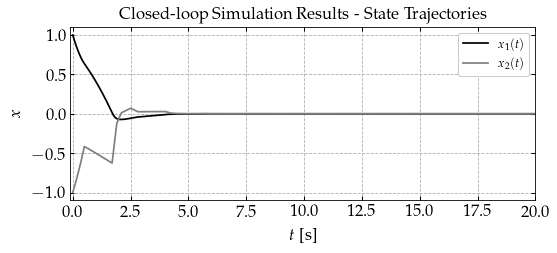

In [8]:
idx = 0
time = batch_results[idx]['time']
states = batch_results[idx]['states'].T

fig, axs = plt.subplot_mosaic([['x']], figsize=(8, 3))
_ = gph.plot(
    axs['x'], time, [states[0], states[1]],
    label=[r'$x_1(t)$', r'$x_2(t)$'],
    title='Closed-loop Simulation Results - State Trajectories',
    xlabel='$t$', x_unit='s', x_use_prefixes=True,
    ylabel=fr'$x$', color=['black', 'gray'],
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

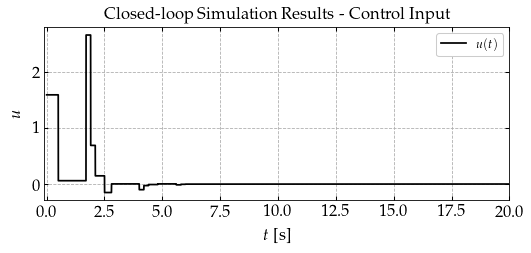

In [9]:
signal_control = batch_results[idx]['control']

fig, axs = plt.subplot_mosaic([['u']], figsize=(8, 3))
_ = gph.plot(
    axs['u'], time, signal_control,
    label=[r'$u(t)$'], xlabel='$t$',
    x_unit='s', x_use_prefixes=True,
    title='Closed-loop Simulation Results - Control Input',
    ylabel=fr'$u$', color=['black', 'gray'],
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

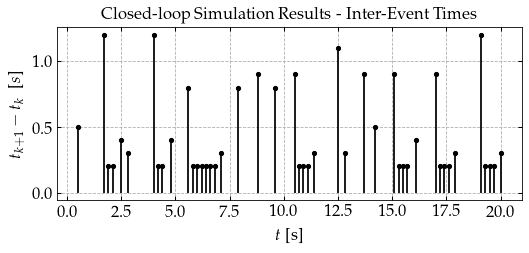

In [10]:
events = batch_results[idx]['events']
iet = np.diff(events)

fig, axs = plt.subplot_mosaic([['iet']], figsize=(8, 3))
_ = gph.stem(
    axs['iet'], events[1:], iet, y_pad=(0.0, 0.05), x_use_prefixes=True,
    xlabel='$t$', x_unit='s', x_range=(0.0, time[-1]),
    title='Closed-loop Simulation Results - Inter-Event Times',
    ylabel='$t_{k+1} - t_k\\;$ [$s$]',
    cfg={'limits': {'x_min': 0, 'x_max': time[-1]},
         'style': {'color': "black"}})

In [11]:
def _create_embedding_matrix(x, order):
  """Cria matriz de embutimento para entropia."""
  n = len(x) - order + 1
  return np.array([x[i:i + order] for i in range(n)])


def calculate_sampen(iet, order=2, r=0.2):
  """Calcula a Sample Entropy manualmente."""
  iet = np.array(iet)
  std = np.std(iet)
  tolerance = r * std

  def count_matches(m):
    phi = _create_embedding_matrix(iet, m)
    dist = np.max(np.abs(phi[:, np.newaxis] - phi), axis=2)
    return np.sum(dist < tolerance) - len(phi)

  return -np.log(count_matches(order + 1) / count_matches(order))


def calculate_apen(iet, order=2, r=0.2):
  """Calcula a Approximate Entropy manualmente."""
  iet = np.array(iet)
  std = np.std(iet)
  tolerance = r * std

  def phi(m):
    mat = _create_embedding_matrix(iet, m)
    dist = np.max(np.abs(mat[:, np.newaxis] - mat), axis=2)
    return np.sum(np.log(np.sum(dist < tolerance, axis=1) / len(mat))) / len(mat)

  return phi(order) - phi(order + 1)


def calculate_pe(iet, order=3):
  """Calcula a Permutation Entropy manualmente."""
  n = len(iet)
  # Gera as permutações ordinais
  sorted_idx = np.array([np.argsort(iet[i:i + order])
                        for i in range(n - order + 1)])

  # Conta a frequência de cada padrão
  _, counts = np.unique(sorted_idx, axis=0, return_counts=True)
  probs = counts / len(sorted_idx)

  # Cálculo da entropia: usa math.factorial para evitar o erro de atributo do numpy
  return -np.sum(probs * np.log(probs)) / math.log(math.factorial(order))


def analyze_iet_sequence(iet_sequence):
  """Analisa a sequência de IETs sem dependência da biblioteca antropy."""
  iet = np.array(iet_sequence)
  if len(iet) < 10:  # Entropias exigem amostras mínimas
    return "Sequência muito curta para análise."

  # Métricas Estatísticas
  mean_iet = np.mean(iet)
  std_iet = np.std(iet, ddof=1)

  results = {
      "num_transmissions": len(iet),
      "min": np.min(iet),
      "max": np.max(iet),
      "mean": mean_iet,
      "std": std_iet,
      "cv": std_iet / mean_iet if mean_iet != 0 else 0,
      "avg_rate": 1.0 / mean_iet,
      "skewness": skew(iet),
      # Entropias sem dependência externa
      "apen": calculate_apen(iet),
      "sampen": calculate_sampen(iet),
      "pe": calculate_pe(iet)
  }
  return results


def print_iet_analysis(results):
  """Exibe o dicionário de resultados de forma organizada."""
  if isinstance(results, str):
    print(results)
    return

  print(f"{'='*45}")
  print(f"{'ANÁLISE DE INTERVALOS ENTRE EVENTOS (IET)':^45}")
  print(f"{'='*45}")

  print(f"{'MÉTRICAS ESTATÍSTICAS':<30}")
  print(f"{'- Número de Transmissões:':<30} {results['num_transmissions']}")
  print(f"{'- Média (Mean):':<30} {results['mean']:.6f} s")
  print(f"{'- Desvio Padrão (Std):':<30} {results['std']:.6f} s")
  print(f"{'- Coef. de Variação (CV):':<30} {results['cv']:.4f}")
  print(f"{'- Mínimo:':<30} {results['min']:.6f} s")
  print(f"{'- Máximo:':<30} {results['max']:.6f} s")
  print(f"{'- Taxa Média (Rate):':<30} {results['avg_rate']:.2f} Hz")
  print(f"{'- Assimetria (Skewness):':<30} {results['skewness']:.4f}")

  print(f"\n{'MÉTRICAS DE CAOS / ENTROPIA':<30}")
  print(f"{'- Entropia Aprox (ApEn):':<30} {results['apen']:.4f}")
  print(f"{'- Sample Entropy (SampEn):':<30} {results['sampen']:.4f}")
  print(f"{'- Permutation Ent. (PE):':<30} {results['pe']:.4f}")
  print(f"{'='*45}")

In [12]:
analysis_results = analyze_iet_sequence(iet)
print_iet_analysis(analysis_results)

  ANÁLISE DE INTERVALOS ENTRE EVENTOS (IET)  
MÉTRICAS ESTATÍSTICAS         
- Número de Transmissões:      45
- Média (Mean):                0.444444 s
- Desvio Padrão (Std):         0.337474 s
- Coef. de Variação (CV):      0.7593
- Mínimo:                      0.200000 s
- Máximo:                      1.200000 s
- Taxa Média (Rate):           2.25 Hz
- Assimetria (Skewness):       1.1027

MÉTRICAS DE CAOS / ENTROPIA   
- Entropia Aprox (ApEn):       0.5360
- Sample Entropy (SampEn):     1.0198
- Permutation Ent. (PE):       0.7619


In [13]:
def control_synthesis_mtd(
    design_params: Dict[str, float],
    mtd_params: Dict[str, Any],
    eps: float = 1e-6,
    dtype=np.float32
):
  def _create_problem_data() -> ProblemData:
    model = simulator.lpv_model
    _nx = len(model['states'])
    _nu = len(model['inputs'])
    _np = len(model['parameters'])
    p_bounds = [param['bounds'] for param in model['parameters'].values()]

    _h = design_params['h']
    _υ = design_params['υ']
    _λ = design_params['λ']

    Bnp = list(itertools.product([0, 1], repeat=_np))
    _A, _B = {}, {}
    param_names = list(model['parameters'].keys())

    for i in Bnp:
      rho_dict = {param_names[idx]: p_bounds[idx][i[idx]]
                  for idx in range(_np)}
      mat_A = simulator.get_matrix("A", rho_dict)
      mat_B = simulator.get_matrix("B", rho_dict)
      _A[i] = cp.Parameter((_nx, _nx), value=mat_A.astype(dtype))
      _B[i] = cp.Parameter((_nx, _nu), value=mat_B.astype(dtype))

    I_total = np.eye(5 * _nx, dtype=dtype)
    _e = [None] + [cp.Parameter((_nx, 5 * _nx),
                                value=I_total[(k-1)*_nx: k*_nx, :]) for k in range(1, 6)]

    return ProblemData(
        nx=_nx, nu=_nu, nρ=_np, h=_h, υ=_υ, λ=_λ,
        A=_A, B=_B, e=_e, dtype=dtype
    )

  def _create_variables(data: ProblemData) -> DecisionVariables:
    nx = data.nx
    nu = data.nu
    e_shape_1 = data.e[1].shape[1]

    _Ktil, _Ξtil, _Ψtil = {}, {}, {}
    for p in range(mtd_params['n_modes']):
      for r in range(mtd_params['n_regions']):
        _Ktil[(p, r)] = cp.Variable((nu, nx))
        _Ξtil[(p, r)] = cp.Variable((nx, nx), PSD=True)
        _Ψtil[(p, r)] = cp.Variable((nx, nx), PSD=True)

    return DecisionVariables(
        Ptil=cp.Variable((nx, nx), PSD=True),
        Mtil=cp.Variable((2 * nx, 2 * nx), PSD=True),
        Q1til=cp.Variable((nx, nx), symmetric=True),
        Q2til=cp.Variable((nx, nx)),
        Q3til=cp.Variable((nx, nx)),
        S1til=cp.Variable((nx, nx), symmetric=True),
        S2til=cp.Variable((nx, nx)),
        S3til=cp.Variable((nx, nx)),
        Ktil=_Ktil,
        Rtil=cp.Variable((nx, nx), PSD=True),
        Ξtil=_Ξtil,
        Ψtil=_Ψtil,
        X=cp.Variable((nx, nx)),
        Ytil=cp.Variable((2 * nx, e_shape_1))
    )

  def _build_constants(data: ProblemData, vars: DecisionVariables) -> Constants:
    nx = data.nx
    e = data.e
    υ = data.υ
    λ = data.λ
    h = data.h

    _Onx = np.zeros((nx, nx), dtype=data.dtype)
    _exp_λh = np.exp(-2. * λ * h)

    _Rcal = cp.bmat([[(vars.Rtil), _Onx], [_Onx, 3. * (vars.Rtil)]])
    _Fscr = e[1].T + float(υ) * e[2].T + float(υ) * e[4].T
    _κ1 = cp.bmat([[e[2]], [e[5]]])
    _κ2 = cp.bmat([[e[1] - e[2]], [e[1] + e[2] - 2. * e[3]]])

    def He(matrix_expr):
      return matrix_expr + matrix_expr.T

    _Λ1 = (e[1] - e[2]).T @ vars.S1til @ (e[1] - e[2]) + \
        He((e[1] - e[2]).T @ (vars.S2til @ e[2] + vars.S3til @ e[5]))

    _Λ2 = _κ1.T @ vars.Mtil @ _κ1 - e[4].T @ vars.Rtil @ e[4] - e[3].T @ vars.Q1til @ e[3] + \
        He((e[1] - e[2]).T @ vars.S1til @ e[4] + e[4].T @ vars.S2til @ e[2] +
           e[4].T @ vars.S3til @ e[5] + e[1].T @ vars.Q1til @ e[3] +
           e[1].T @ vars.Q2til @ e[2] + e[1].T @ vars.Q3til @ e[5])

    _Λ3 = e[3].T @ vars.Q1til @ e[3] + _κ1.T @ vars.Mtil @ _κ1 + \
        He(e[3].T @ (vars.Q2til @ e[2] + vars.Q3til @ e[5]))

    return Constants(
        Onx=_Onx, exp_λh=_exp_λh, Rcal=_Rcal, Fscr=_Fscr,
        κ1=_κ1, κ2=_κ2, Λ1=_Λ1, Λ2=_Λ2, Λ3=_Λ3
    )

  data = _create_problem_data()
  vars = _create_variables(data)
  consts = _build_constants(data, vars)

  Bnp = list(itertools.product([0, 1], repeat=data.nρ))
  constraints = []

  def He(matrix_expr):
    return matrix_expr + matrix_expr.T

  for p in range(mtd_params['n_modes']):
    for r in range(mtd_params['n_regions']):
      Ξtil_esp = 0
      Ψtil_esp = 0
      for q in range(mtd_params['n_modes']):
        prob = float(mtd_params['pi'][p, q, r])
        if prob > 0:
          Ξtil_esp += prob * vars.Ξtil[(q, r)]
          Ψtil_esp += prob * vars.Ψtil[(q, r)]

      for i in Bnp:
        Bscr = data.A[i] @ vars.X @ data.e[1] + \
            data.B[i] @ vars.Ktil[(p, r)] @ data.e[2] + \
            data.B[i] @ vars.Ktil[(p, r)] @ data.e[5] - \
            vars.X @ data.e[4]

        Θ0 = - data.e[5].T @ Ξtil_esp @ data.e[5] - 2. * data.λ * consts.exp_λh * consts.Λ1 + \
            (1. - consts.exp_λh) * consts.Λ2 + \
            He(consts.Fscr @ Bscr + data.e[1].T @ vars.Ptil @ data.e[4] +
               data.λ * data.e[1].T @ vars.Ptil @ data.e[1] +
               2. * data.λ * consts.exp_λh * consts.κ2.T @ vars.Ytil)

        Θh = - data.e[5].T @ Ξtil_esp @ data.e[5] - \
            2. * data.λ * consts.exp_λh * \
            (consts.Λ1 + data.h * consts.Λ3 - He(consts.κ2.T @ vars.Ytil)) + \
            He(consts.Fscr @ Bscr + data.e[1].T @ vars.Ptil @
               data.e[4] + data.λ * data.e[1].T @ vars.Ptil @ data.e[1])

        Γ1 = cp.bmat([[Θ0, data.e[2].T @ vars.X.T],
                      [vars.X @ data.e[2], -Ψtil_esp]])

        _Γ13 = data.e[2].T @ vars.X.T
        _Γ22 = -(np.exp(2. * data.λ * data.h) /
                 (2. * data.λ * data.h)) * consts.Rcal
        _Γ23 = np.zeros((2 * data.nx, data.nx), dtype=dtype)
        _Γ32 = np.zeros((data.nx, 2 * data.nx), dtype=dtype)

        Γ2 = cp.bmat([[Θh, vars.Ytil.T, _Γ13],
                      [vars.Ytil, _Γ22, _Γ23],
                      [vars.X @ data.e[2], _Γ32, -Ψtil_esp]])

        constraints += [Γ1 << -eps * np.eye(Γ1.shape[0], dtype=dtype)]
        constraints += [Γ2 << -eps * np.eye(Γ2.shape[0], dtype=dtype)]

      constraints += [vars.Ψtil[(p, r)] >>
                      eps * np.eye(data.nx, dtype=dtype)]
      constraints += [vars.Ξtil[(p, r)] >>
                      eps * np.eye(data.nx, dtype=dtype)]

  constraints += [vars.Ptil >> eps * np.eye(data.nx, dtype=dtype)]

  w_mtd = mtd_params.get('w_mtd', {(p, r): 1.0 for p in range(
      mtd_params['n_modes']) for r in range(mtd_params['n_regions'])})
  obj_expr = 0.0
  for p in range(mtd_params['n_modes']):
    for r in range(mtd_params['n_regions']):
      weight = float(w_mtd[(p, r)]) if isinstance(
          w_mtd, dict) else float(w_mtd[p, r])
      obj_expr += weight * \
          (cp.trace(vars.Ξtil[(p, r)]) + cp.trace(vars.Ψtil[(p, r)]))

  problem = cp.Problem(cp.Minimize(obj_expr), constraints)
  problem.solve(solver=cp.MOSEK, verbose=False, ignore_dpp=True)

  # --- Pós-Processamento e Reconstrução Física ---
  design_results = None
  if problem.status not in ["infeasible", "unbounded"]:
    X_val = vars.X.value.astype(dtype)
    Xinv = np.linalg.inv(X_val)
    XinvT = Xinv.T

    Xinv_2x = np.block([[Xinv, np.zeros((data.nx, data.nx), dtype=dtype)],
                        [np.zeros((data.nx, data.nx), dtype=dtype), Xinv]])
    XinvT_2x = Xinv_2x.T

    Ξ, Ψ, K = {}, {}, {}
    for p in range(mtd_params['n_modes']):
      for r in range(mtd_params['n_regions']):
        Ξ[(p, r)] = XinvT @ vars.Ξtil[(p, r)].value.astype(dtype) @ Xinv
        Ψ[(p, r)] = np.linalg.inv(vars.Ψtil[(p, r)].value.astype(dtype))
        K[(p, r)] = vars.Ktil[(p, r)].value.astype(dtype) @ Xinv

    design_results = {
        'optimal_value': problem.value,
        'etm': {'Ξ': Ξ, 'Ψ': Ψ},
        'controller': {'K': K},
        'functional': {
            'P': XinvT @ vars.Ptil.value.astype(dtype) @ Xinv,
            'R': XinvT @ vars.Rtil.value.astype(dtype) @ Xinv,
            'M': XinvT_2x @ vars.Mtil.value.astype(dtype) @ Xinv_2x,
            'S1': XinvT @ vars.S1til.value.astype(dtype) @ Xinv,
            'S2': XinvT @ vars.S2til.value.astype(dtype) @ Xinv,
            'S3': XinvT @ vars.S3til.value.astype(dtype) @ Xinv,
            'Q1': XinvT @ vars.Q1til.value.astype(dtype) @ Xinv,
            'Q2': XinvT @ vars.Q2til.value.astype(dtype) @ Xinv,
            'Q3': XinvT @ vars.Q3til.value.astype(dtype) @ Xinv,
            'Y': XinvT_2x @ vars.Ytil.value.astype(dtype)
        },
    }

  return design_results

In [29]:
import numpy as np
from datetime import datetime

n_modes = 10
n_regions = 10
SEED = 10000

design_params_exp = {**design_params, 'λ': 0.1}
rng = np.random.default_rng(SEED)
pi = np.zeros((n_modes, n_modes, n_regions), dtype=np.float32)

for r in range(n_regions):
  for p in range(n_modes):
    alpha = np.ones(n_modes) * 0.5
    pi[p, :, r] = rng.dirichlet(alpha)


design_params['υ'] = 1e-1
print("lambda (λ): ", design_params_exp['λ'])

print("Matriz de Transição de Modo (pi):")
for r in range(n_regions):
  print(f"\n📍 Região {r} (r = {r}):")
  print(np.array2string(
      pi[:, :, r],
      formatter={'float_kind': lambda x: f"{x:.2f}"}
  ))

lambda (λ):  0.1
Matriz de Transição de Modo (pi):

📍 Região 0 (r = 0):
[[0.02 0.09 0.41 0.05 0.05 0.05 0.06 0.23 0.00 0.05]
 [0.04 0.04 0.01 0.13 0.13 0.18 0.07 0.09 0.29 0.02]
 [0.02 0.59 0.01 0.12 0.02 0.03 0.05 0.04 0.12 0.00]
 [0.00 0.79 0.02 0.05 0.01 0.02 0.02 0.05 0.00 0.05]
 [0.09 0.01 0.39 0.01 0.02 0.04 0.08 0.06 0.26 0.05]
 [0.24 0.21 0.02 0.04 0.05 0.00 0.00 0.00 0.43 0.00]
 [0.00 0.04 0.01 0.02 0.12 0.00 0.02 0.30 0.33 0.15]
 [0.14 0.00 0.24 0.49 0.04 0.00 0.00 0.01 0.01 0.06]
 [0.20 0.13 0.10 0.00 0.01 0.08 0.00 0.05 0.20 0.24]
 [0.01 0.05 0.41 0.04 0.00 0.23 0.00 0.00 0.02 0.23]]

📍 Região 1 (r = 1):
[[0.17 0.28 0.02 0.02 0.05 0.09 0.03 0.17 0.10 0.08]
 [0.01 0.02 0.04 0.06 0.19 0.00 0.33 0.00 0.03 0.32]
 [0.02 0.00 0.15 0.05 0.01 0.69 0.02 0.01 0.04 0.01]
 [0.37 0.00 0.00 0.05 0.00 0.06 0.00 0.03 0.01 0.47]
 [0.13 0.01 0.03 0.00 0.05 0.06 0.05 0.30 0.19 0.17]
 [0.01 0.01 0.00 0.23 0.03 0.25 0.38 0.02 0.04 0.03]
 [0.13 0.01 0.18 0.03 0.00 0.17 0.20 0.00 0.17 0.11]
 [0.0

In [32]:
w_mtd = np.array([[0.2, 0.1, 0.4, 0.9, 0.5, 0.3, 0.7, 0.6, 0.8, 0.4],
                  [0.5, 0.2, 0.6, 0.8, 0.4, 0.1, 0.9, 0.7, 0.3, 0.5],
                  [0.3, 0.4, 0.1, 0.6, 0.7, 0.8, 0.2, 0.9, 0.5, 0.1],
                  [0.6, 0.7, 0.5, 0.2, 0.8, 0.9, 0.1, 0.3, 0.4, 0.2],
                  [0.4, 0.8, 0.3, 0.5, 0.9, 0.2, 0.6, 0.1, 0.7, 0.3],
                  [0.7, 0.6, 0.9, 0.4, 0.2, 0.3, 0.8, 0.5, 0.1, 0.4],
                  [0.8, 0.9, 0.2, 0.7, 0.1, 0.5, 0.4, 0.3, 0.6, 0.2],
                  [0.9, 0.3, 0.8, 0.1, 0.6, 0.4, 0.5, 0.2, 0.7, 0.1],
                  [0.1, 0.5, 0.7, 0.3, 0.4, 0.6, 0.9, 0.8, 0.2, 0.5],
                  [0.5, 0.4, 0.6, 0.2, 0.3, 0.7, 0.1, 0.9, 0.8, 0.3]])
print("Pesos MTD (baseados na diagonal de pi):")
print(w_mtd)

# w_mtd = np.array([[0.2, 0.8],
#                   [0.75, 0.25]])

mtd_params = {
    'n_modes': n_modes,
    'n_regions': n_regions,
    'pi': pi,
    'w_mtd': w_mtd
}

Pesos MTD (baseados na diagonal de pi):
[[0.2 0.1 0.4 0.9 0.5 0.3 0.7 0.6 0.8 0.4]
 [0.5 0.2 0.6 0.8 0.4 0.1 0.9 0.7 0.3 0.5]
 [0.3 0.4 0.1 0.6 0.7 0.8 0.2 0.9 0.5 0.1]
 [0.6 0.7 0.5 0.2 0.8 0.9 0.1 0.3 0.4 0.2]
 [0.4 0.8 0.3 0.5 0.9 0.2 0.6 0.1 0.7 0.3]
 [0.7 0.6 0.9 0.4 0.2 0.3 0.8 0.5 0.1 0.4]
 [0.8 0.9 0.2 0.7 0.1 0.5 0.4 0.3 0.6 0.2]
 [0.9 0.3 0.8 0.1 0.6 0.4 0.5 0.2 0.7 0.1]
 [0.1 0.5 0.7 0.3 0.4 0.6 0.9 0.8 0.2 0.5]
 [0.5 0.4 0.6 0.2 0.3 0.7 0.1 0.9 0.8 0.3]]


In [33]:
Ξ = Ψ = K = L1 = P = γ = β = None
optimal_value = None
design_params = {'h': 0.1, 'υ': 0.1, 'λ': 0.1}

results_mtd = control_synthesis_mtd(design_params, mtd_params)
if results_mtd is not None:
  optimal_value = results_mtd['optimal_value']
  etm_modes = results_mtd['etm']
  lyapunov_matrices = results_mtd['functional']
  K_modes = results_mtd['controller']['K']

  print("================ GLOBAL RESULTS ================")
  print(f"Optimal Value (Objective): {optimal_value:.4f}\n")
  # P global única e uniforme para garantir robustez de chaveamento
  P_lyap = lyapunov_matrices['P']
  display(Math(rf'P = {tex.mat2tex(P_lyap)}'))
  print("\n")

  print("================ MTD MODE AND REGION DEPENDENT RESULTS ================")
  for p in range(n_modes):
    print(f"\n⚡ MODE {p + 1} ⚡")
    print("=" * 30)

    for r in range(n_regions):
      print(f"\n📍 Region {r} (r = {r})")

      # Recupera as matrizes variantes de interesse real do MTD
      Ξ_pr = etm_modes['Ξ'][(p, r)]
      Ψ_pr = etm_modes['Ψ'][(p, r)]
      K_pr = K_modes[(p, r)]

      # Renderiza os parâmetros variantes legítimos da tática de defesa
      display(Math(rf'K_{{{p+1},{r}}} = {tex.mat2tex(K_pr)}'))
      display(Math(rf'\Xi_{{{p+1},{r}}} = {tex.mat2tex(Ξ_pr)}'))
      display(Math(rf'\Psi_{{{p+1},{r}}} = {tex.mat2tex(Ψ_pr)}'))
      print("-" * 30)

    print("=" * 50)
else:
  print("❌ O problema de otimização restou Inexequível (Infeasible) ou Ilimitado (Unbounded).")

================ GLOBAL RESULTS ================
Optimal Value (Objective): 0.0025



<IPython.core.display.Math object>



================ MTD MODE AND REGION DEPENDENT RESULTS ================

⚡ MODE 1 ⚡

📍 Region 0 (r = 0)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

------------------------------

📍 Region 9 (r = 9)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

------------------------------


In [34]:
def calcular_limites_por_decaimento(design_params, mtd_params):
  """
  Calcula analiticamente a lista de thresholds (c) para QUALQUER quantidade
  de regiões (n_regions) com base na taxa de decaimento exponencial (lambda).

  Retorna uma lista de floats com tamanho (n_regions - 1).
  """
  h = design_params['h']
  λ = design_params['λ']
  n_regions = mtd_params['n_regions']

  if n_regions <= 1:
    return []

  # Fator base de decaimento de energia em um passo amostral h
  fator_base = np.exp(-2. * λ * h)

  thresholds = []
  for k in range(1, n_regions):
    # Implementa a equação: ck = (e^(-2*lambda*h))^(n_regions - k)
    ck = float(fator_base ** (n_regions - k))
    thresholds.append(ck)

  return thresholds

In [35]:
c = calcular_limites_por_decaimento(design_params, mtd_params)
display(c)

[0.8352702114112717,
 0.852143788966211,
 0.8693582353988055,
 0.8869204367171573,
 0.9048374180359593,
 0.9231163463866356,
 0.9417645335842486,
 0.9607894391523231,
 0.9801986733067553]

In [41]:
import numpy as np

# --- 1. Extração de dimensões e parâmetros estruturais do dicionário results_mtd ---
# Chaves no formato (modo, regiao)
etm_keys = list(results_mtd['etm']['Ξ'].keys())
n_modes = max(k[0] for k in etm_keys) + 1
n_regions = max(k[1] for k in etm_keys) + 1

# --- 2. Construção das tabelas de matrizes para o C++ [Modo][Região] ---
# Inicializamos listas vazias de tamanho adequado para guardar os arrays
K_table = [[None for _ in range(n_regions)] for _ in range(n_modes)]
Xi_table = [[None for _ in range(n_regions)] for _ in range(n_modes)]
Psi_table = [[None for _ in range(n_regions)] for _ in range(n_modes)]

for p in range(n_modes):
  for r in range(n_regions):
    # Conversão explícita para float64 (exigido pela DLL em C++)
    K_table[p][r] = results_mtd['controller']['K'][(
        p, r)].astype(np.float64)
    Xi_table[p][r] = results_mtd['etm']['Ξ'][(p, r)].astype(np.float64)
    Psi_table[p][r] = results_mtd['etm']['Ψ'][(p, r)].astype(np.float64)

# --- 3. Recuperação de W e tratamento adaptativo dos limiares c ---
# A matriz W do MTD é dada diretamente pelo P global unificado do Lyapunov funcional
W = results_mtd['functional']['P'].astype(np.float64)

# Como o seu cálculo 'c' possui tamanho (n_regions - 1), nós o convertemos para array
# de forma que o C++ possa iterar sobre as fronteiras internas exatamente como implementado.
c_array = np.ascontiguousarray(c, dtype=np.float64)

# --- 4. Configuração dos Cenários de Simulação ---
# Definimos as condições iniciais que queremos simular em paralelo
x0_list = [
    np.array([1.0, -1.0], dtype=np.float64)
]

# Tensor de transição Pi das imagens (exemplo ilustrativo de preenchimento)
# Deve possuir a dimensão [n_modes, n_modes, n_regions]
pi_tensor = pi

# --- 5. Disparando a Simulação Paralela com Sementes Aleatórias (Caso 2) ---
# Simularemos os 3 x0 em 10 execuções aleatórias distintas para cada um (total = 30 cenários)[cite: 7]
results = simulator.run_closed_loop_mtd_simulation(
    x0_list=x0_list,
    # Caso 2: C++ gera sementes aleatórias e retorna para o Python[cite: 7, 8]
    num_simulations=1,
    K_table=K_table,
    Xi_table=Xi_table,
    Psi_table=Psi_table,
    pi_tensor=pi_tensor,
    W=W,
    c=c_array,
    sampling_period=0.1,
    sample_time=0.0001,
    duration=20.0
)

In [43]:
# Analisando o primeiro cenário simulado
primeiro_cenario = results[0]

# [cite: 7, 8]
print(f"Semente utilizada pelo C++: {primeiro_cenario['seed']}")
print(f"Número de transmissões (IETs): {len(primeiro_cenario['events'])}")
# [cite: 7, 8]
print(f"Histórico de Modos ativos: {primeiro_cenario['modes']}")
# [cite: 7, 8]
print(f"Histórico de Regiões de energia: {primeiro_cenario['regions']}")

Semente utilizada pelo C++: 2451720881
Número de transmissões (IETs): 44
Histórico de Modos ativos: [9 7 8 4 6 5 0 8 7 9 9 0 8 3 9 0 1 2 8 3 2 2 8 5 0 8 9 0 4 5 3 2 0 8 3 1 6
 9 5 4 3 1 7 3 2 5 9 7 7 2 5 4 6 9 0 8 7 4 5 8 9 7 7 7 8 3 6 9 7 7 8 0 8 8
 7 0 8 5 1 1 0 8 7 2 4 2 4 2 9 5 9 5 1 7 5 4 2 5 9 5 6 9 5 7 8 7 8 2 2 0 0
 2 5 6 5 4 9 4 6 9 7 6 8 2 0 1 0 7 4 1 6 9 9 5 9 5 4 2 7 2 3 6 0 7 2 5 0 1
 4 4 7 2 3 3 3 3 6 9 9 6 5 4 4 5 4 8 8 2 9 0 7 1 1 2 3 5 1 1 1 6 0 1 5 4 2
 7 5 4 6 9 9 5 4 7 0 4 7 1 2 1 7]
Histórico de Regiões de energia: [9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9
 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 8 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


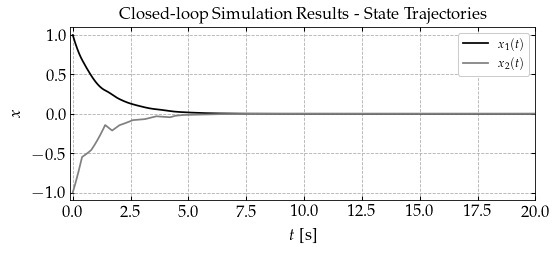

In [44]:
idx = 0
time = results[idx]['time']
states = results[idx]['states'].T

fig, axs = plt.subplot_mosaic([['x']], figsize=(8, 3))
_ = gph.plot(
    axs['x'], time, [states[0], states[1]],
    label=[r'$x_1(t)$', r'$x_2(t)$'],
    title='Closed-loop Simulation Results - State Trajectories',
    xlabel='$t$', x_unit='s', x_use_prefixes=True,
    ylabel=fr'$x$', color=['black', 'gray'],
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

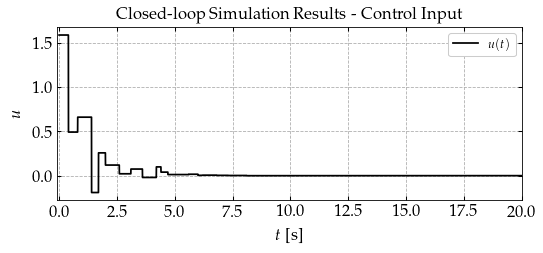

In [45]:
signal_control = results[idx]['control']

fig, axs = plt.subplot_mosaic([['u']], figsize=(8, 3))
_ = gph.plot(
    axs['u'], time, signal_control,
    label=[r'$u(t)$'], xlabel='$t$',
    x_unit='s', x_use_prefixes=True,
    title='Closed-loop Simulation Results - Control Input',
    ylabel=fr'$u$', color=['black', 'gray'],
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

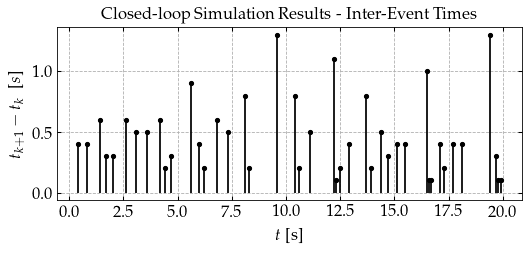

In [46]:
events = results[idx]['events']
iet = np.diff(events)

fig, axs = plt.subplot_mosaic([['iet']], figsize=(8, 3))
_ = gph.stem(
    axs['iet'], events[1:], iet, y_pad=(0.0, 0.05), x_use_prefixes=True,
    xlabel='$t$', x_unit='s', x_range=(0.0, time[-1]),
    title='Closed-loop Simulation Results - Inter-Event Times',
    ylabel='$t_{k+1} - t_k\\;$ [$s$]',
    cfg={'limits': {'x_min': 0, 'x_max': time[-1]},
         'style': {'color': "black"}})

In [47]:
def plot_mtd_schedule_professional(time_samples, mode_history, event_time):
  # Encontra os índices dos eventos no tempo de amostragem
  # Como event_time pode não cair exatamente em um ponto de amostragem,
  # usamos searchsorted para encontrar o instante de amostragem mais próximo
  event_indices = np.searchsorted(time_samples, event_time) - 1
  event_indices = np.clip(event_indices, 0, len(mode_history) - 1)

  event_mode_history = mode_history[event_indices]

  max_mode_idx = np.max(mode_history)

  fig, ax = plt.subplots(figsize=(6, 3))

  # Agora time_samples (201) e mode_history (201) possuem a mesma dimensão
  ax.step(
      time_samples, mode_history,
      where='post', color='black', linewidth=1.0, label=r'$\sigma(t)$'
  )

  if len(event_time) > 0:
    ax.scatter(
        event_time, event_mode_history,
        color='red', s=8, zorder=3, label='Transmissões'
    )

  ax.set_title('MTD Schedule (Amplo)', fontsize=10, fontweight='bold')
  ax.set_xlabel('$t$ (s)')
  ax.set_ylabel(r'MTD Mode')
  ax.set_xlim(0, time_samples[-1])
  ax.grid(True, linestyle='--', alpha=0.4)
  plt.tight_layout()
  plt.show()

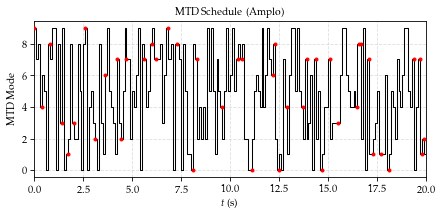

In [48]:
# 1. Obtenha os dados do resultado
idx = 0
mode_history = results[idx]["modes"]      # Tamanho: 201
event_time = results[idx]["events"]       # Instantes onde o ETM disparou
duration = 20.0                           # Duração total

# 2. Crie o vetor de tempo de amostragem (correto para o tamanho dos dados salvos)
# O número de pontos é len(mode_history), que corresponde aos 200.001 / (dt/periodo)
time_samples = np.linspace(0, duration, len(mode_history))

# 3. Chame a função passando o tempo amostrado, não o tempo total da simulação
plot_mtd_schedule_professional(time_samples, mode_history, event_time)